In [ ]:
from functions import generate_H, generate_D, generate_F, compute_costs, accumulate_traces, pick_direction, gradient_analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

The following code blocks can be used to generate new data. Otherwise, it can be loaded from data.

In [2]:
# B = 36 # Number of visual bins, evenly distributed around the agent
# scale = 50  # length of one side of the H map in meters
# resolution = 10 # Simulated units/meter
# sigma = 40 # sigma of sine wave / major slope in degrees
# noise_scale = 0 # Noise applied to H(x,y,t=0)

# # Generate H 
# x, y, H0, size, offsets = generate_H(scale, resolution, sigma, noise_scale, plot=False)

# # Critical parameters
# beta = 50 # Energy landscape sensitivity
# alpha = -0.1 #The depth of the agent's footprint. How quickly the environment erodes. 
# delta = 0.5*resolution #Footprint interval.
# eta = 0.5*resolution #resolution
# L = 10*resolution

# # Generate the footprint map
# r_F = 1*resolution
# F = generate_F(r_F) #radius*2)

# # Initialize the depletion layer
# R = np.ones([size, size])

# # Generate the depletion map
# r_D = 2*resolution
# D = generate_D(r_D) #radius*2)
# gamma = -1 # resource depletion strength
# mu = 0.1 # resource regrowth rate
# w_v = 8.25 # vertical motion cost scalar
# w_h = 0.95 # horizontal motion cost scalar 

# max_steps = 50000
# num_steps = 0
# plt_interval = max_steps//20
# max_erosion = resolution*1.5
# abs_erosion = 0 
# save_interval = 10

# # Create the enviroment for modification (gradient_layer)
# H = H0.copy()

# omega = 2*resolution # gradient analysis window size 

# # Randomly initiate agents 
# N = 1 # number of agents 
# agent_pos = size*np.random.rand(2,N)

In [ ]:
# repeats = 10

# for N in [1,3,5]:
    
#     for sigma in [0, 20, 40]:
#         # Generate H 
#         x, y, H0, size, offsets = generate_H(scale, resolution, sigma, noise_scale, plot=False)    
        
#         for repeat in np.arange(10)+10: 
#             # Create the enviroment for modification (gradient_layer)
#             H = H0.copy()
#             #Randomly initiate agents 
#             agent_pos = size*np.random.rand(2,N)
#             num_steps = 0
#             abs_erosion = 0 
#             # Initialize the depletion layer
#             R = np.ones([size, size])
            

#             while (num_steps <= max_steps) and (abs_erosion <= max_erosion):
                
#                 R += mu
#                 R[R > 1] = 1

#                 for j in range(N): 
#                     # Compute costs along potential paths     
#                     angles_mesh, radial_mesh, gradient, depletion = compute_costs(agent_pos[:,j], B, delta, L, H, R, size, offsets, resolution)
#                     # Pick a new direction and update agent position
#                     agent_pos[:,j], line, angle, entropy = pick_direction(agent_pos[:,j], beta, angles_mesh, radial_mesh, gradient, depletion, w_h, w_v, delta, size)
#                     # Update gradient layer 
#                     H, _ = accumulate_traces(H, F, line, alpha, eta)    
#                     deviation = H0 - H
#                     abs_erosion = np.max(deviation) - np.min(deviation)
                    
#                     # Update resource layer
#                     R, _ = accumulate_traces(R, D, line, gamma, 0)
#                     R[R < 0] = 0
                    
#                 num_steps += 1
                
#             # Compute gradient analysis? 
#             if num_steps != 0:
#                 _, mean_gradient, mean_coherence = gradient_analysis(deviation, omega)
#                 print(mean_coherence)
                
#             data = [mean_coherence, num_steps]
                
#             np.save(f'SIfig02/{N}_{sigma}_{repeat}.npy', np.array(data))
                    
#             # Plot an update of terrain and resource erosion
#             fig, axs = plt.subplots(ncols=2, figsize=(10,20))
#             axs[0].imshow(deviation - np.min(deviation), origin='lower', cmap='jet', extent=(0, scale, 0, scale))
#             axs[0].set_title(f't = {num_steps}, abs_erosion = {abs_erosion}')
#             axs[1].imshow(R, origin='lower', cmap='Greens', extent=(0, scale, 0, scale))
#             axs[1].set_title(f't = {num_steps}')
#             plt.show()

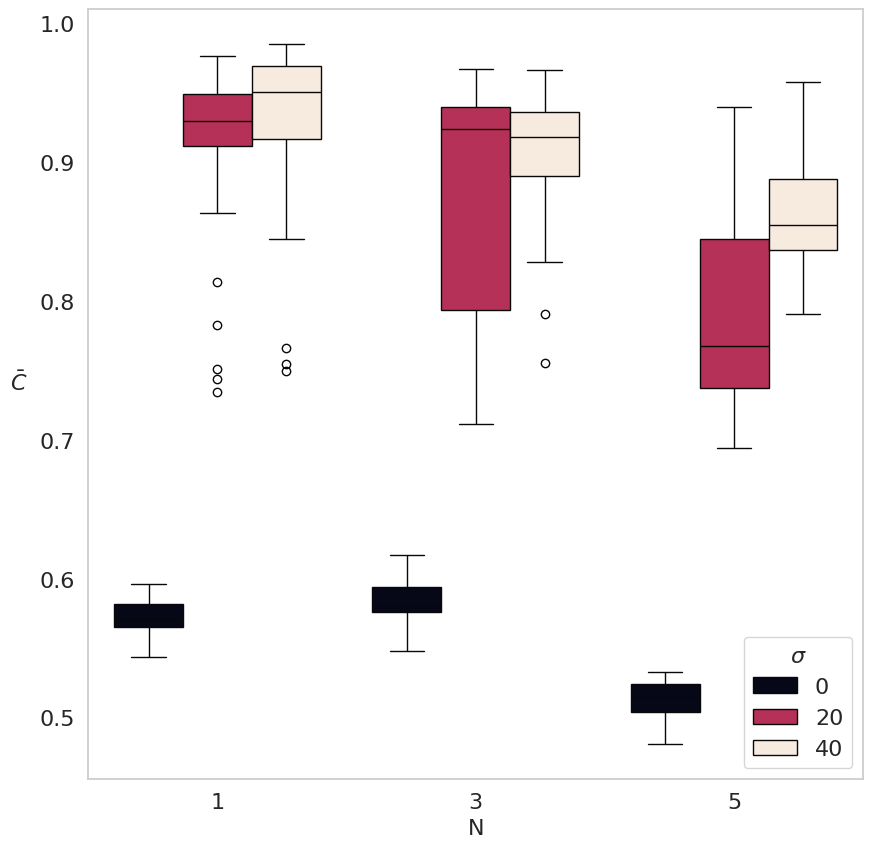

In [ ]:
sns.set_theme(style="whitegrid")

repeats = 30
Ns = [1,3,5]
sigmas = [0, 20, 40]

N_list = []
C_list = []
time_list = []
sigma_list = []

for N in Ns: 
    for sigma in sigmas:
        for repeat in range(repeats): 
            temp = np.load(f'SIfig02/{N}_{sigma}_{repeat}.npy')
            N_list.append(N)
            sigma_list.append(sigma)
            C_list.append(temp[0])
            time_list.append(temp[1])
            
df = pd.DataFrame({'N': N_list, 'sigma': sigma_list, 'timesteps':time_list, 'coherence':C_list})


# Initialize the figure
f, ax = plt.subplots(figsize=(10,10))
#sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.boxplot(data=df, x="N", y="coherence", hue="sigma", zorder=0, legend=True, palette="rocket"
)
plt.legend(title=r"$\sigma$", title_fontsize=16, fontsize=16, loc='lower right')
plt.xlabel("N", fontsize=16)
plt.ylabel(r"$\bar{C}$", fontsize=16, labelpad=15, rotation=0)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax.grid(False)

# plt.savefig('Figures/simulation_time_coherence.png', transparent=True, bbox_inches='tight')

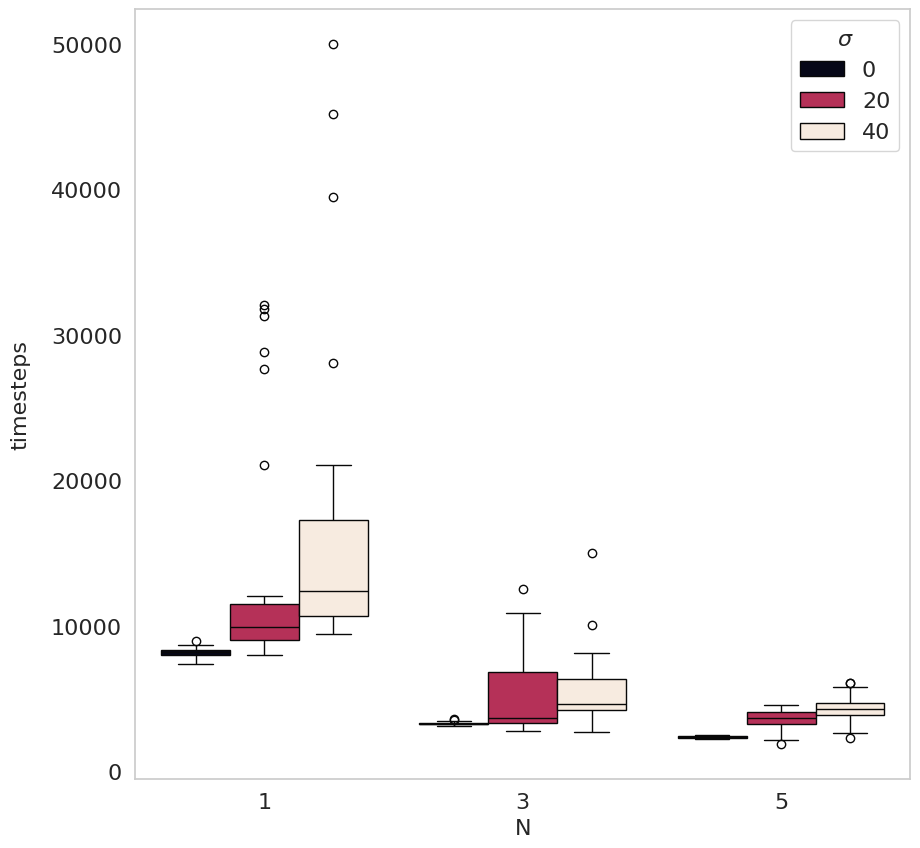

In [ ]:
sns.set_theme(style="whitegrid")

repeats = 30
Ns = [1,3,5]
sigmas = [0, 20, 40]

N_list = []
C_list = []
time_list = []
sigma_list = []

for N in Ns: 
    for sigma in sigmas:
        for repeat in range(repeats): 
            temp = np.load(f'SIfig02/{N}_{sigma}_{repeat}.npy')
            N_list.append(N)
            sigma_list.append(sigma)
            C_list.append(temp[0])
            time_list.append(temp[1])
            
df = pd.DataFrame({'N': N_list, 'sigma': sigma_list, 'timesteps':time_list, 'coherence':C_list})


# Initialize the figure
f, ax = plt.subplots(figsize=(10,10))
#sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.boxplot(data=df, x="N", y="timesteps", hue="sigma", zorder=0, legend=True, palette="rocket"
)
plt.legend(title=r"$\sigma$", title_fontsize=16, fontsize=16, loc='upper right')
plt.xlabel("N", fontsize=16)
plt.ylabel(r"timesteps", fontsize=16, labelpad=15)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax.grid(False)

# plt.savefig('Figures/simulation_time_steps.png', transparent=True, bbox_inches='tight')